In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/amazon_reviews_raw.csv")
print(df.shape)
df.head()

(71496, 3)


,rating,title,text
0,5.0,Great pictures and recipes,Wonderful recipes in this magazine.
1,4.0,great for kids who love sports!,Great sports magazine that's on my 9 year olds...
2,5.0,A great look at what's new on the kosher scene...,"""Joy of Kosher"" magazine fills a much-needed n..."
3,5.0,"If you enjoy reading an eye-catching, easy-to-...",I've been addicted to Martha Stewart's Everyda...
4,1.0,Too many “ gear ads” !!,Too many ads!


In [3]:
def map_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['rating'].apply(map_sentiment)
df['sentiment'].value_counts()

sentiment
positive    52825
negative    13638
neutral      5033
Name: count, dtype: int64

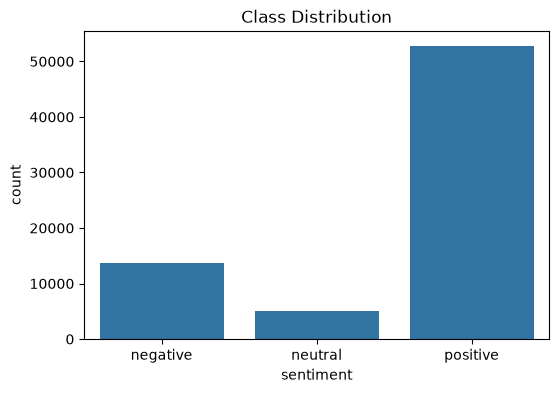

In [4]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', order=['negative','neutral','positive'])
plt.title("Class Distribution")
plt.show()

In [12]:
df = df.dropna(subset=['text']).reset_index(drop=True)
print(df.shape)

(65229, 5)


count    71496.000000
mean        38.340075
std         63.574826
min          0.000000
25%          8.000000
50%         21.000000
75%         43.000000
max       4888.000000
Name: text_length, dtype: float64


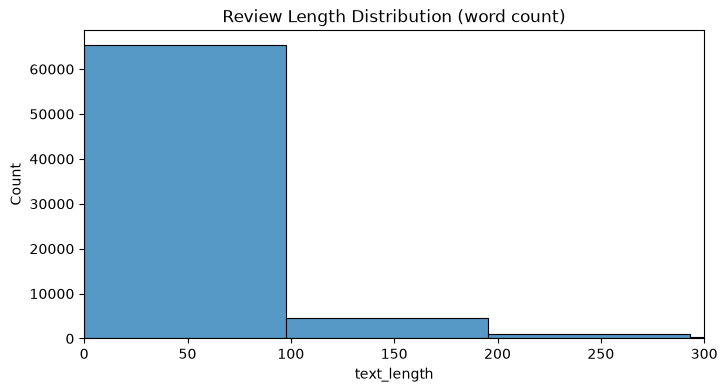

In [7]:
df['text_length'] = df['text'].fillna('').astype(str).apply(lambda x: len(x.split()))

print(df['text_length'].describe())

plt.figure(figsize=(8,4))
sns.histplot(df['text_length'], bins=50)
plt.title("Review Length Distribution (word count)")
plt.xlim(0, 300)
plt.show()

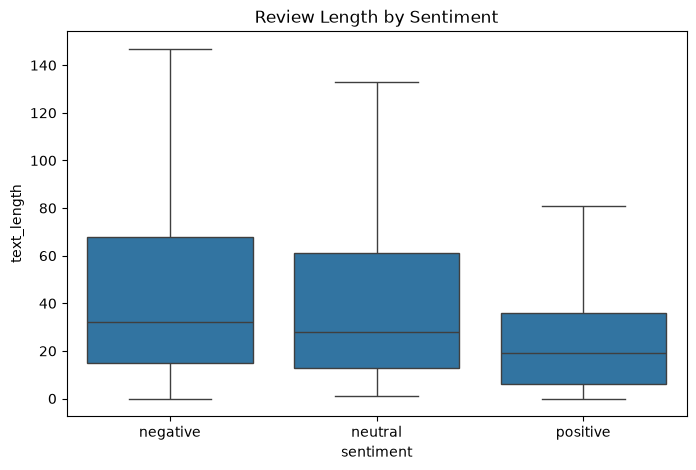

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentiment', y='text_length', order=['negative','neutral','positive'], showfliers=False)
plt.title("Review Length by Sentiment")
plt.show()

In [9]:
print("Duplicate rows:", df.duplicated(subset=['text']).sum())
print("Duplicate %:", round(df.duplicated(subset=['text']).sum() / len(df) * 100, 2), "%")

Duplicate rows: 6266
Duplicate %: 8.76 %


In [10]:
df[df.duplicated(subset=['text'], keep=False)].sort_values('text').head(20)[['rating', 'text']]

,rating,text
5923,5.0,"---If you found this review helpful, please cl..."
5924,5.0,"---If you found this review helpful, please cl..."
5925,5.0,"---If you found this review helpful, please cl..."
5920,5.0,"---If you found this review helpful, please cl..."
5921,5.0,"---If you found this review helpful, please cl..."
5922,5.0,"---If you found this review helpful, please cl..."
61671,5.0,.my whole family is enjoying this magazine and...
61672,5.0,.my whole family is enjoying this magazine and...
45680,5.0,1
60265,5.0,1


In [11]:
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(df.shape)
print(df['sentiment'].value_counts())

(65230, 5)
sentiment
positive    47163
negative    13279
neutral      4788
Name: count, dtype: int64


In [13]:
from collections import Counter
import re

In [14]:
def get_top_words(text_series, n=20):
    all_words = []
    for text in text_series:
        words = re.findall(r'\b[a-z]+\b', str(text).lower())
        all_words.extend(words)
    return Counter(all_words).most_common(n)

for sentiment in ['negative', 'neutral', 'positive']:
    print(f"\n--- Top words: {sentiment} ---")
    subset = df[df['sentiment'] == sentiment]['text']
    print(get_top_words(subset, 20))


--- Top words: negative ---
[('the', 31138), ('i', 28023), ('to', 21613), ('and', 19363), ('a', 17593), ('it', 14427), ('of', 13523), ('magazine', 11559), ('is', 10346), ('for', 10192), ('this', 10078), ('not', 8687), ('in', 8543), ('that', 8509), ('br', 7917), ('my', 6926), ('was', 6004), ('t', 5934), ('have', 5809), ('you', 5462)]

--- Top words: neutral ---
[('the', 11860), ('i', 9661), ('to', 6879), ('and', 6546), ('a', 6182), ('it', 5762), ('of', 5152), ('magazine', 3972), ('is', 3884), ('for', 3536), ('in', 3113), ('that', 3013), ('this', 2890), ('but', 2845), ('not', 2788), ('br', 2593), ('my', 2060), ('s', 2046), ('t', 1990), ('are', 1909)]

--- Top words: positive ---
[('the', 72126), ('and', 55956), ('i', 54995), ('to', 45991), ('a', 41801), ('it', 36746), ('magazine', 33493), ('of', 32968), ('for', 28979), ('this', 27659), ('is', 26847), ('in', 20821), ('my', 18332), ('that', 16030), ('br', 15832), ('great', 14031), ('you', 13535), ('are', 12481), ('have', 12349), ('on', 12

In [15]:
br_count = df['text'].str.contains('<br', case=False, na=False).sum()
print(f"Reviews containing HTML <br> tags: {br_count} ({round(br_count/len(df)*100, 2)}%)")

Reviews containing HTML <br> tags: 7190 (11.02%)


In [16]:
df.to_csv("../data/amazon_reviews_cleaned.csv", index=False)
print("Saved cleaned data:", df.shape)

Saved cleaned data: (65229, 5)
